<a href="https://colab.research.google.com/github/harishmuh/Deep-Learning_study/blob/main/Image_Classification_with_CNN_CIFAR10_pytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---
# **Image classification - CIFAR10 dataset**
---

![image](https://corochann.com/wp-content/uploads/2021/09/cifar10_plot_more-700x700-1.png)

### **Context**

In this study, we will build neural network with CNN to classify image of objects in Cifar-10 dataset using pytorch.

### **About CIFAR-10 dataset**

CIFAR-10 contains:

* 60,000 color images

* 32 × 32 pixels

* 3 color channels (RGB)

* 10 object classes (airplane, car, bird, cat, deer, dog, frog, horse, ship, truck)

![image](https://www.researchgate.net/profile/Abien-Fred-Agarap/publication/337731039/figure/fig3/AS:832268801171466@1575439753171/Figure-from-9-The-CIFAR-10-dataset-is-a-benchmark-image-classification-dataset-with-10.ppm)

### **Convolutional Neural Network (CNN)**

The CNN model is a type of deep neural network designed primarily for processing grid-structured data such as images. It uses convolutional layers to automatically extract spatial features (e.g., edges, textures, shapes) through local connections and shared weights, making it more efficient than fully connected networks for visual tasks.

**Initial setup**

In [1]:
# Importing libraries
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

**Loading dataset and transform**

In [2]:
# Loading dataset CIFAR-10
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
# train set
trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=32, shuffle=True)


100%|██████████| 170M/170M [00:05<00:00, 29.0MB/s]


In [3]:
# test set
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=32, shuffle=False)

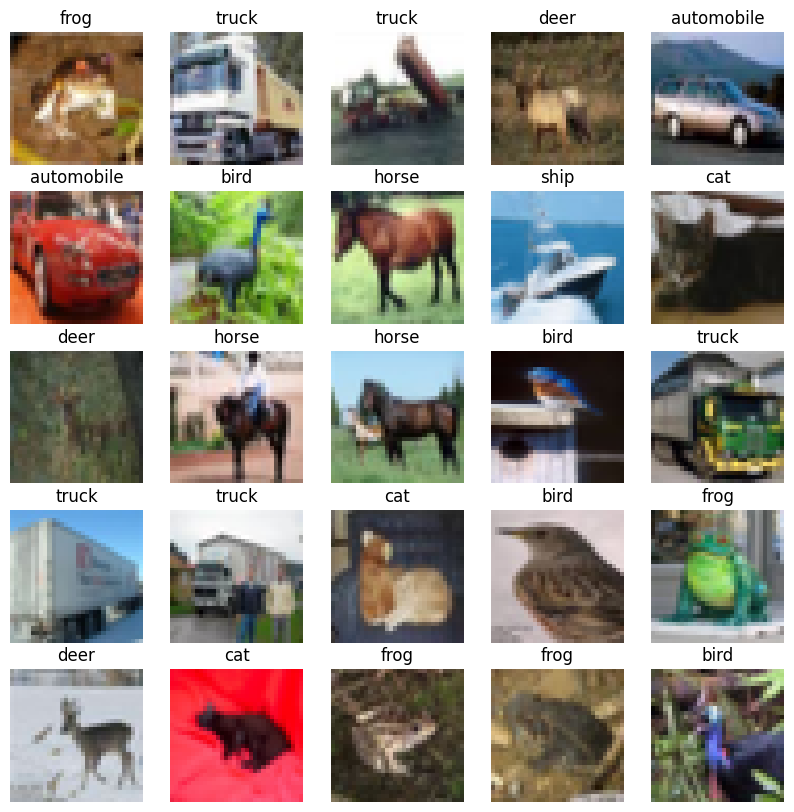

In [8]:
# Displaying some images from train set
import matplotlib.pyplot as plt
import numpy as np

# Verifying the data
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

# Displaying six images
plt.figure(figsize=(10,10))

for i in range(25):
  plt.subplot(5,5,i+1)
  img, label = trainset[i]
  img = img.numpy().transpose((1, 2, 0))
  img = (img * 0.5) + 0.5
  plt.imshow(img)
  plt.title(class_names[label])
  plt.axis('off')
plt.show()


### **Model Building**

In [9]:
# CNN architecture
class CNN(nn.Module):
  def __init__(self):
    super(CNN, self).__init__()
    self.conv1 = nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1)
    self.pool = nn.MaxPool2d(2,2)
    self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
    self.fc1 = nn.Linear(64*8*8, 128)
    self.fc2 = nn.Linear(128, 10) # Corrected from 512 to 128

  def forward(self, x):
    x = self.pool(torch.relu(self.conv1(x)))
    x = self.pool(torch.relu(self.conv2(x)))
    x = x.view(-1, 64*8*8)
    x = torch.relu(self.fc1(x))
    x = self.fc2(x)
    return x

In [10]:
# Model initialization, loss function, and optimizer
model = CNN()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [11]:
# Model training
from torch.nn.modules import loss

for epoch in range(10):
  running_loss = 0.0
  for images, labels in trainloader:
    optimizer.zero_grad()
    outputs = model(images)
    loss = criterion(outputs, labels)
    loss.backward()
    optimizer.step()
    running_loss += loss.item()
  print(f'Epoch: {epoch+1}, Loss: {running_loss / len(trainloader)}')


Epoch: 1, Loss: 1.2645104234598419
Epoch: 2, Loss: 0.9036364582625247
Epoch: 3, Loss: 0.7537672441698234
Epoch: 4, Loss: 0.6303087714022729
Epoch: 5, Loss: 0.5241531077784296
Epoch: 6, Loss: 0.4309392390547467
Epoch: 7, Loss: 0.33998439572537015
Epoch: 8, Loss: 0.27355393429149133
Epoch: 9, Loss: 0.21359404980163885
Epoch: 10, Loss: 0.1724171005606518


### **Model Evaluation**

In [12]:
# Model evaluation
correct = 0
total = 0

with torch.no_grad():
  for images, labels in testloader:
    outputs = model(images)
    _, predicted = torch.max(outputs.data, 1)
    total += labels.size(0)
    correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f'Accuracy of the network on the 10000 test images: {accuracy:.2f}%')

Accuracy of the network on the 10000 test images: 70.43%


### **Conclusion**

We have 70.43% accuracy. We may need to improve the model to further increase the accuracy.